# Health Insurance Lead Prediction: Data Cleaning & Exploratory Data Analysis (EDA)

In this notebook, we will load the raw dataset, handle missing values, and perform exploratory data analysis to understand the key factors driving health insurance lead conversions.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Create visualizations directory if it doesn't exist
os.makedirs('../visualizations', exist_ok=True)

# Load the dataset
# We use openpyxl engine for .xlsx files
try:
    df = pd.read_excel('../data/raw/Health Insurance Lead Prediction.xlsx', sheet_name='Sheet1')
    print(f"Dataset loaded successfully with {df.shape[0]} rows and {df.shape[1]} columns.")
except Exception as e:
    print(f"Error loading dataset: {e}")


Dataset loaded successfully with 50884 rows and 16 columns.


In [2]:
# Display the first few rows
df.head()


,ID,City_Code,Region_Code,Accomodation_Type,Reco_Insurance_Type,Upper_Age,Lower_Age,Is_Spouse,Health Indicator,Holding_Policy_Duration,Holding_Policy_Type,Reco_Policy_Cat,Reco_Policy_Premium,Response,Column1,Unnamed: 15
0,1.0,C3,3213.0,Rented,Individual,36.0,36.0,No,X1,14.0,3.0,22.0,11628.0,0.0,1.0,NaN
1,2.0,C5,1117.0,Owned,Joint,75.0,22.0,No,X2,NaN,NaN,22.0,30510.0,0.0,1.0,NaN
2,3.0,C5,3732.0,Owned,Individual,32.0,32.0,No,NaN,1.0,1.0,19.0,7450.0,1.0,1.0,NaN
3,4.0,C24,4378.0,Owned,Joint,52.0,48.0,No,X1,14.0,3.0,19.0,17780.0,0.0,1.0,NaN
4,5.0,C8,2190.0,Rented,Individual,44.0,44.0,No,X2,3.0,1.0,16.0,10404.0,0.0,1.0,NaN


In [3]:
# Check for missing values
missing_values = df.isnull().sum()
print("Missing Values:\n", missing_values[missing_values > 0])


Missing Values:
 ID                             2
City_Code                      2
Region_Code                    2
Accomodation_Type              2
Reco_Insurance_Type            2
Upper_Age                      2
Lower_Age                      2
Is_Spouse                      2
Health Indicator           11693
Holding_Policy_Duration    20253
Holding_Policy_Type        20253
Reco_Policy_Cat                2
Reco_Policy_Premium            2
Response                       1
Column1                        2
Unnamed: 15                50883
dtype: int64


In [4]:
# Handle missing values
# Drop rows where target variable is missing or invalid
if 'Response' in df.columns:
    df = df.dropna(subset=['Response'])
    df = df[df['Response'].isin([0, 1])]

# Impute Health Indicator with mode
if 'Health Indicator' in df.columns:
    df['Health Indicator'] = df['Health Indicator'].fillna(df['Health Indicator'].mode()[0])

# Impute Holding_Policy_Duration with median or mode, or treat as a separate category
if 'Holding_Policy_Duration' in df.columns:
    # Since it's categorical (e.g., '14+', '1.0'), we replace missing with '0' (No previous policy)
    df['Holding_Policy_Duration'] = df['Holding_Policy_Duration'].fillna('0')
    
# Verify missing values are handled
print("Missing values after cleaning:\n", df.isnull().sum().sum())


Missing values after cleaning:
 71132


C:\Users\nshar\AppData\Local\Temp\ipykernel_6800\399817467.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Response', data=df, palette='viridis')


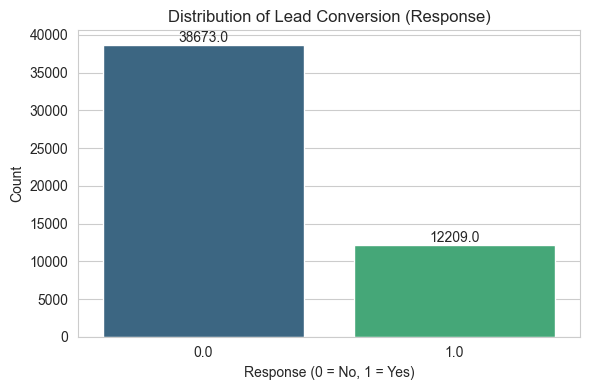

In [5]:
# Exploratory Data Analysis (EDA)
sns.set_style('whitegrid')

# 1. Lead Conversion Rate
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='Response', data=df, palette='viridis')
plt.title('Distribution of Lead Conversion (Response)')
plt.xlabel('Response (0 = No, 1 = Yes)')
plt.ylabel('Count')

# Annotate bars
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom')

plt.tight_layout()
plt.savefig('../visualizations/lead_conversion_rate.png', dpi=300)
plt.show()


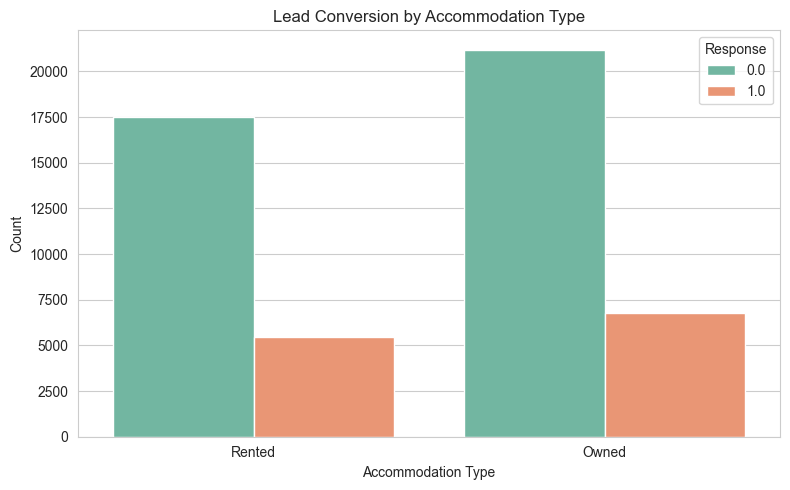

In [6]:
# 2. Conversion by Accomodation Type
plt.figure(figsize=(8, 5))
sns.countplot(x='Accomodation_Type', hue='Response', data=df, palette='Set2')
plt.title('Lead Conversion by Accommodation Type')
plt.xlabel('Accommodation Type')
plt.ylabel('Count')
plt.legend(title='Response')
plt.tight_layout()
plt.savefig('../visualizations/conversion_by_accommodation.png', dpi=300)
plt.show()


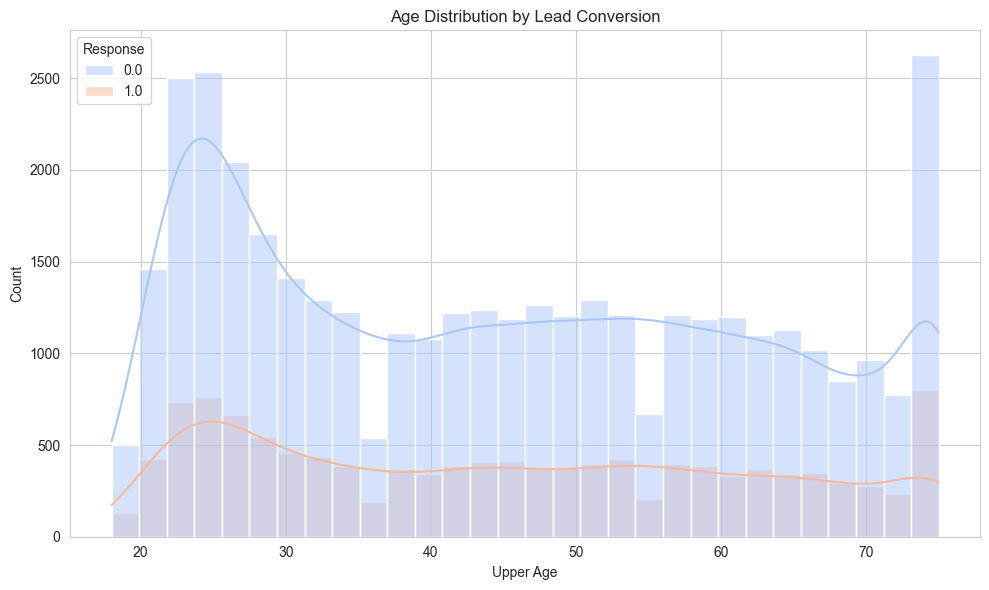

In [7]:
# 3. Age Distribution of Leads vs Non-Leads
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Upper_Age', hue='Response', bins=30, kde=True, palette='coolwarm')
plt.title('Age Distribution by Lead Conversion')
plt.xlabel('Upper Age')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('../visualizations/age_distribution.png', dpi=300)
plt.show()


C:\Users\nshar\AppData\Local\Temp\ipykernel_6800\1037616944.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Response', y='Reco_Policy_Premium', data=df, palette='pastel')


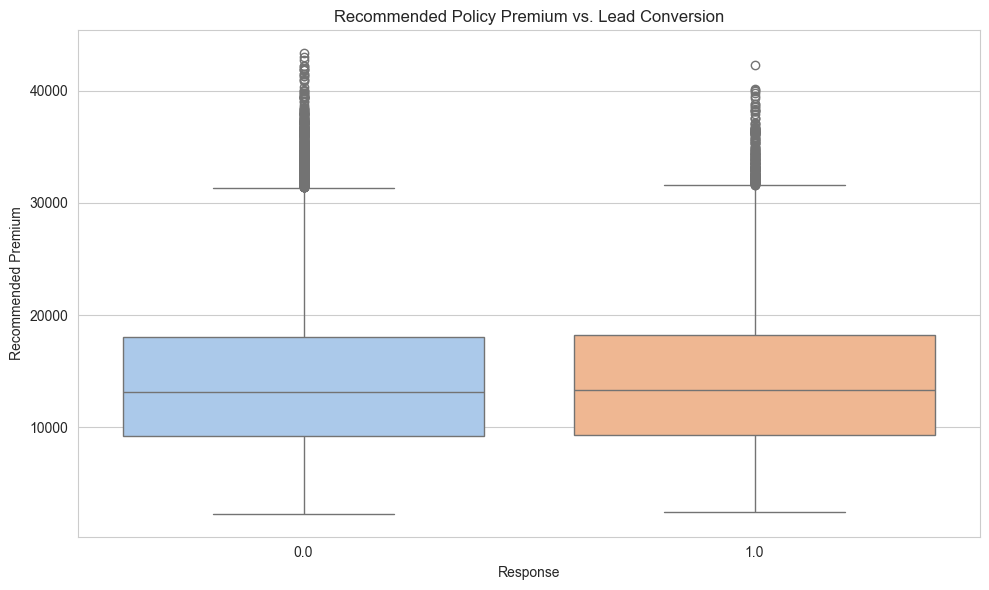

In [8]:
# 4. Impact of Recommended Policy Premium
plt.figure(figsize=(10, 6))
sns.boxplot(x='Response', y='Reco_Policy_Premium', data=df, palette='pastel')
plt.title('Recommended Policy Premium vs. Lead Conversion')
plt.xlabel('Response')
plt.ylabel('Recommended Premium')
plt.tight_layout()
plt.savefig('../visualizations/premium_vs_conversion.png', dpi=300)
plt.show()


In [9]:
# Save the cleaned dataset for the modeling phase
df.to_csv('../data/processed/cleaned_health_insurance.csv', index=False)
print("Cleaned dataset saved to data/processed/")


Cleaned dataset saved to data/processed/
